# Evaluación 2 — Bases aprendidas vs. Fourier
**Programación Científica 2026-1 · Universidad Nacional de Colombia**
ID personalizado: **1591**

Pregunta guía: ¿ayuda empezar con la base "correcta" (Fourier) en lugar de una base
aleatoria, al entrenar una red que reconstruye una señal?

## 0. Preparación

In [2]:
# --- Librerías ---
import numpy as np                       # utilidades numéricas fuera de JAX (indexado, argmax, etc.)
import jax                                # motor de diferenciación automática y compilación (jit)
import jax.numpy as jnp                   # numpy "diferenciable" que corre dentro de JAX
from jax import random, grad, jit, vmap   # random: manejo de semillas; grad: gradiente automático;
                                           # jit: compilación; vmap: vectorización sobre batches
import matplotlib.pyplot as plt           # graficas

# --- Semilla global ---
# Usamos el ID de la evaluación como semilla para que todo el notebook
# sea reproducible: cualquiera que lo corra de nuevo obtiene los mismos
# pesos iniciales y, por lo tanto, las mismas curvas de pérdida.
SEED = 1591
key = random.PRNGKey(SEED)

## Parte I — El fenómeno físico

En un medio **sin dispersión** todas las frecuencias viajan igual y una
onda mantiene su forma. En un medio **dispersivo**, distintas frecuencias
viajan a distinta velocidad. Los datos de esta evaluación vienen de un
medio dispersivo.

Cada modo tiene un número de onda entero k, y la regla del medio le
asigna una frecuencia:

$$\omega(k) = \sqrt{c^2 k^2 + \mu^2}$$

Si µ=0 las frecuencias son bajas; si µ>0, el término µ² empuja las
frecuencias hacia arriba. El parámetro µ define los tres regímenes
(`y` en los datos): 0 = sin dispersión, 1 = intermedia, 2 = fuerte.

Un sensor fijo mide la suma de los modos en el tiempo:

$$f(t) = \sum_j a_j \cos(\omega(k_j)\, t + \varphi_j)$$

Es decir: **cada señal es una suma de cosenos a frecuencias bien
definidas**, justo lo que una base de senos y cosenos representa con
pocos coeficientes. Esta idea es la que verificamos más adelante con
la capa de Fourier.

## Parte II — Los datos

El enunciado especifica que los datos se generan con los 4 últimos
dígitos del ID (1591) y contienen **15 señales por régimen** (45 en
total). Cada señal es un vector `f(t)` de 256 puntos, muestreado en un
sensor fijo, y su etiqueta `y` indica el régimen de dispersión (0, 1 o 2)
descrito en la Parte I.

Cargamos el archivo `datos_1591.npz` ya generado y dejamos separados los
arreglos que usaremos en todo el notebook: `X` (señales), `y` (régimen) y
`t` (grilla temporal).

In [3]:
# Cargamos el archivo .npz generado con el ID personalizado 1591
datos = np.load("datos_1591.npz")

X = jnp.array(datos["X"])   # (45, 256) -> cada fila es una señal f(t)
y = np.array(datos["y"])    # (45,)     -> regimen: 0, 1 o 2 (se deja en numpy, es solo indexado)
t = jnp.array(datos["t"])   # (256,)    -> grilla temporal en la que se muestreo cada señal

N = X.shape[1]   # 256 puntos por señal (tamaño de entrada/salida de la red)
K = 25           # numero de frecuencias de la capa de Fourier (fijado por el enunciado)

print(f"Señales totales: {X.shape[0]}  |  puntos por señal (N): {N}")
print(f"Regimenes disponibles: {np.unique(y)}  (15 señales cada uno)")

Señales totales: 45  |  puntos por señal (N): 256
Regimenes disponibles: [0 1 2]  (15 señales cada uno)


### Verificación visual del fenómeno

Con los datos ya cargados, confirmamos lo descrito en la Parte I:
graficamos una señal de cada régimen y esperamos ver oscilaciones cada
vez más rápidas a medida que aumenta el régimen (µ mayor empuja ω(k)
hacia arriba).

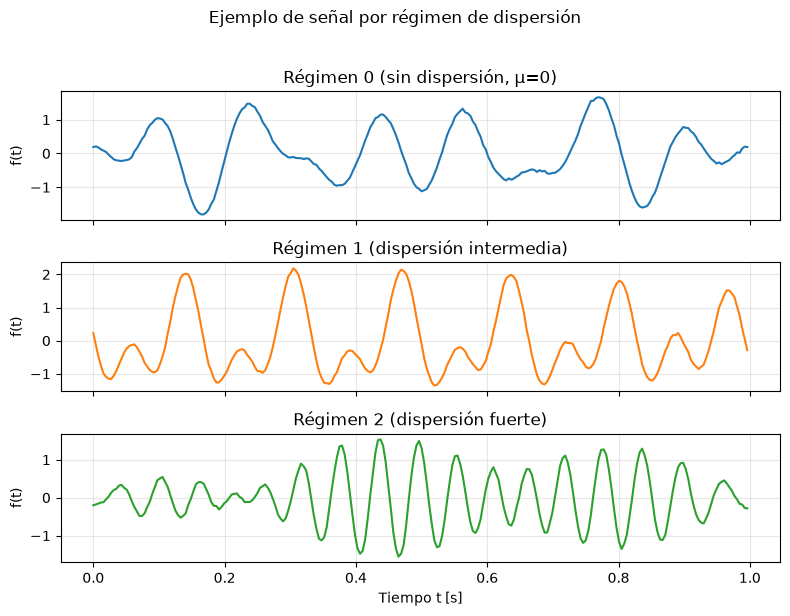

In [4]:
# Diccionario de etiquetas legibles, se reutiliza en todo el notebook
etiquetas = {
    0: "Régimen 0 (sin dispersión, µ=0)",
    1: "Régimen 1 (dispersión intermedia)",
    2: "Régimen 2 (dispersión fuerte)",
}

fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

for r in range(3):
    idx = np.where(y == r)[0][0]          # indice de la primera señal de ese regimen
    axes[r].plot(t, X[idx], color=f"C{r}")
    axes[r].set_ylabel("f(t)")
    axes[r].set_title(etiquetas[r])
    axes[r].grid(alpha=0.3)

axes[-1].set_xlabel("Tiempo t [s]")
fig.suptitle("Ejemplo de señal por régimen de dispersión", y=1.02)
fig.tight_layout()
plt.show()